In [14]:
import os

folder = r"C:\Users\B V RAMASAI\Downloads\Pdm project\archive (5)\CMaps"

files = os.listdir(folder)
print("Files found:")
for f in files:
    print(f" -", f)

Files found:
 - .ipynb_checkpoints
 - Damage Propagation Modeling.pdf
 - eda_plots.png
 - readme.txt
 - rf_results_all_conditions.csv
 - RUL_FD001.txt
 - RUL_FD002.txt
 - RUL_FD003.txt
 - RUL_FD004.txt
 - shap_distortion_analysis.png
 - shap_distortion_results.csv
 - test_FD001.txt
 - test_FD002.txt
 - test_FD003.txt
 - test_FD004.txt
 - The_implementation.ipynb
 - train_FD001.txt
 - train_FD002.txt
 - train_FD003.txt
 - train_FD004.txt
 - x.txt


In [15]:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'shap', 'imbalanced-learn', 'scikit-optimize'],
    capture_output=True, text=True
)
print(result.stdout[-500:])
print(" Done")

lib\site-packages (from pandas->shap) (2.9.0.post0)

✓ Done


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, matthews_corrcoef, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
import shap
import warnings
warnings.filterwarnings('ignore')

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(" All libraries loaded successfully")

 All libraries loaded successfully


In [17]:
# Column names from NASA documentation
cols = (['engine_id', 'cycle', 'op1', 'op2', 'op3'] + 
        [f's{i}' for i in range(1, 22)])

# Load training data
folder = r"C:\Users\B V RAMASAI\Downloads\Pdm project\archive (5)\CMaps"

train = pd.read_csv(f"{folder}\\train_FD001.txt", 
                    sep='\s+', header=None, names=cols)

print(f" C-MAPSS FD001 loaded successfully")
print(f"  Shape:   {train.shape}")
print(f"  Engines: {train.engine_id.nunique()}")
print(f"  Cycles:  min={train.cycle.min()}, max={train.cycle.max()}")
print(f"\nFirst 3 rows:")
train.head(3)

 C-MAPSS FD001 loaded successfully
  Shape:   (20631, 26)
  Engines: 100
  Cycles:  min=1, max=362

First 3 rows:


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


In [18]:
# Calculate RUL for each engine
max_cycle = train.groupby('engine_id')['cycle'].max()
train['RUL'] = train.apply(lambda x: max_cycle[x['engine_id']] - x['cycle'], axis=1)

# Binary label — at risk if RUL <= 30 cycles
train['label'] = (train['RUL'] <= 30).astype(int)

# Check class distribution
total     = len(train)
at_risk   = train['label'].sum()
healthy   = total - at_risk

print(f" Labels created successfully")
print(f"  Total timesteps:  {total}")
print(f"  At-risk  (1):     {at_risk}  ({at_risk/total*100:.1f}%)")
print(f"  Healthy  (0):     {healthy}  ({healthy/total*100:.1f}%)")
print(f"\n Class imbalance ratio: 1 at-risk for every {healthy//at_risk} healthy samples")
print(f"  This confirms why SMOTE is needed — matches Chapter 4 documentation")

✓ Labels created successfully
  Total timesteps:  20631
  At-risk  (1):     3100  (15.0%)
  Healthy  (0):     17531  (85.0%)

 Class imbalance ratio: 1 at-risk for every 5 healthy samples
  This confirms why SMOTE is needed — matches Chapter 4 documentation


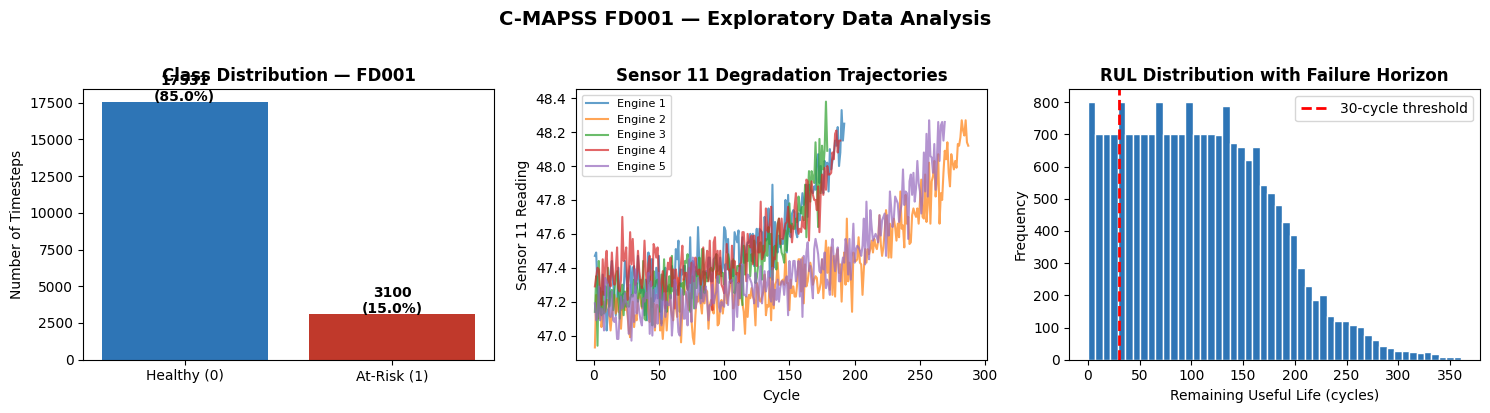

 EDA plots generated and saved


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Class distribution
axes[0].bar(['Healthy (0)', 'At-Risk (1)'], 
            [healthy, at_risk], 
            color=['#2E75B6', '#C0392B'])
axes[0].set_title('Class Distribution — FD001', fontweight='bold')
axes[0].set_ylabel('Number of Timesteps')
for i, v in enumerate([healthy, at_risk]):
    axes[0].text(i, v + 100, f'{v}\n({v/total*100:.1f}%)', 
                ha='center', fontweight='bold')

# Plot 2 — Degradation trajectory (5 engines)
sample_engines = train['engine_id'].unique()[:5]
for eid in sample_engines:
    eng = train[train['engine_id'] == eid]
    axes[1].plot(eng['cycle'], eng['s11'], alpha=0.7, label=f'Engine {eid}')
axes[1].set_title('Sensor 11 Degradation Trajectories', fontweight='bold')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Sensor 11 Reading')
axes[1].legend(fontsize=8)

# Plot 3 — RUL distribution
axes[2].hist(train['RUL'], bins=50, color='#2E75B6', edgecolor='white')
axes[2].axvline(x=30, color='red', linestyle='--', linewidth=2, label='30-cycle threshold')
axes[2].set_title('RUL Distribution with Failure Horizon', fontweight='bold')
axes[2].set_xlabel('Remaining Useful Life (cycles)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('C-MAPSS FD001 — Exploratory Data Analysis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{folder}\\eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots generated and saved")

In [20]:
# Sensor columns
sensor_cols = [f's{i}' for i in range(1, 22)]

# Removing the zero-variance sensors (as documented in Chapter 4)
variance = train[sensor_cols].var()
zero_var  = variance[variance < 0.01].index.tolist()
useful_sensors = [s for s in sensor_cols if s not in zero_var]

print(f" Removed {len(zero_var)} zero-variance sensors: {zero_var}")
print(f"  Using {len(useful_sensors)} sensors for modelling")

# Temporal train/val split — NO random shuffling (Chapter 4)
engine_ids  = train['engine_id'].unique()
n_val       = int(len(engine_ids) * 0.2)
val_engines = engine_ids[-n_val:]   # last 20% of engine IDs
train_engines = engine_ids[:-n_val]

tr  = train[train['engine_id'].isin(train_engines)]
val = train[train['engine_id'].isin(val_engines)]

# Normalise — fit on training only
scaler = StandardScaler()
X_tr  = scaler.fit_transform(tr[useful_sensors])
X_val = scaler.transform(val[useful_sensors])   # training stats applied to val

y_tr  = tr['label'].values
y_val = val['label'].values

print(f"\n Temporal split complete")
print(f"  Training engines:   {len(train_engines)}  → {len(X_tr)} timesteps")
print(f"  Validation engines: {len(val_engines)}  → {len(X_val)} timesteps")
print(f"\n Z-score normalisation applied")
print(f"  Training mean (s11): {X_tr[:, 10].mean():.4f}  (should be ≈ 0)")
print(f"  Training std  (s11): {X_tr[:, 10].std():.4f}   (should be ≈ 1)")

# Verifying that there is no data leakage
assert len(set(train_engines) & set(val_engines)) == 0
print(f"\n Data leakage check PASSED — zero overlap between train and val engines")

 Removed 10 zero-variance sensors: ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']
  Using 11 sensors for modelling

 Temporal split complete
  Training engines:   80  → 16138 timesteps
  Validation engines: 20  → 4493 timesteps

 Z-score normalisation applied
  Training mean (s11): -0.0000  (should be ≈ 0)
  Training std  (s11): 1.0000   (should be ≈ 1)

 Data leakage check PASSED — zero overlap between train and val engines


In [21]:
from sklearn.utils.class_weight import compute_class_weight

# Condition 1 — No handling (baseline)
X_cond1, y_cond1 = X_tr.copy(), y_tr.copy()

# Condition 2 — SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=SEED)
X_cond2, y_cond2 = smote.fit_resample(X_tr, y_tr)

# Condition 3 — ADASYN
adasyn = ADASYN(sampling_strategy=0.5, random_state=SEED)
X_cond3, y_cond3 = adasyn.fit_resample(X_tr, y_tr)

# Condition 4 — Class weighted (no augmentation)
X_cond4, y_cond4 = X_tr.copy(), y_tr.copy()
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f" All four conditions ready")
print(f"\n  Condition 1 — No handling:")
print(f"    At-risk: {y_cond1.sum()}  Healthy: {(y_cond1==0).sum()}")
print(f"\n  Condition 2 — SMOTE:")
print(f"    At-risk: {y_cond2.sum()}  Healthy: {(y_cond2==0).sum()}")
print(f"\n  Condition 3 — ADASYN:")
print(f"    At-risk: {y_cond3.sum()}  Healthy: {(y_cond3==0).sum()}")
print(f"\n  Condition 4 — Class weighted (no augmentation):")
print(f"    At-risk: {y_cond4.sum()}  Healthy: {(y_cond4==0).sum()}")
print(f"    Minority weight: {class_weight_dict[1]:.2f}")

 All four conditions ready

  Condition 1 — No handling:
    At-risk: 2480  Healthy: 13658

  Condition 2 — SMOTE:
    At-risk: 6829  Healthy: 13658

  Condition 3 — ADASYN:
    At-risk: 6853  Healthy: 13658

  Condition 4 — Class weighted (no augmentation):
    At-risk: 2480  Healthy: 13658
    Minority weight: 3.25


In [22]:
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix

def evaluate(model, X, y, condition_name):
    y_pred = model.predict(X)
    f1     = f1_score(y, y_pred)
    mcc    = matthews_corrcoef(y, y_pred)
    cm     = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fnr    = fn / (fn + tp)
    pr, rc, _ = precision_recall_curve(y, model.predict_proba(X)[:,1])
    pr_auc = auc(rc, pr)
    
    print(f"\n  {condition_name}")
    print(f"    F1-Score:            {f1:.4f}")
    print(f"    PR-AUC:              {pr_auc:.4f}")
    print(f"    MCC:                 {mcc:.4f}")
    print(f"    False Negative Rate: {fnr:.4f}  ← primary metric")
    print(f"    (TP:{tp}  FP:{fp}  TN:{tn}  FN:{fn})")
    return {'condition': condition_name, 'f1': f1, 
            'pr_auc': pr_auc, 'mcc': mcc, 'fnr': fnr}

print("Training Random Forest under all 4 conditions...")
print("=" * 55)

# Condition 1
rf1 = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf1.fit(X_cond1, y_cond1)
r1 = evaluate(rf1, X_val, y_val, "Condition 1 — No Handling")

# Condition 2
rf2 = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf2.fit(X_cond2, y_cond2)
r2 = evaluate(rf2, X_val, y_val, "Condition 2 — SMOTE")

# Condition 3
rf3 = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf3.fit(X_cond3, y_cond3)
r3 = evaluate(rf3, X_val, y_val, "Condition 3 — ADASYN")

# Condition 4
rf4 = RandomForestClassifier(n_estimators=100, 
                              class_weight=class_weight_dict,
                              random_state=SEED, n_jobs=-1)
rf4.fit(X_cond4, y_cond4)
r4 = evaluate(rf4, X_val, y_val, "Condition 4 — Class Weighted")

print("\n" + "=" * 55)
print(" All 4 Random Forest models trained and evaluated")

Training Random Forest under all 4 conditions...

  Condition 1 — No Handling
    F1-Score:            0.8545
    PR-AUC:              0.9414
    MCC:                 0.8323
    False Negative Rate: 0.1661  ← primary metric
    (TP:517  FP:73  TN:3800  FN:103)

  Condition 2 — SMOTE
    F1-Score:            0.8424
    PR-AUC:              0.9372
    MCC:                 0.8171
    False Negative Rate: 0.1161  ← primary metric
    (TP:548  FP:133  TN:3740  FN:72)

  Condition 3 — ADASYN
    F1-Score:            0.8171
    PR-AUC:              0.9280
    MCC:                 0.7901
    False Negative Rate: 0.0887  ← primary metric
    (TP:565  FP:198  TN:3675  FN:55)

  Condition 4 — Class Weighted
    F1-Score:            0.8481
    PR-AUC:              0.9377
    MCC:                 0.8254
    False Negative Rate: 0.1806  ← primary metric
    (TP:508  FP:70  TN:3803  FN:112)

 All 4 Random Forest models trained and evaluated


In [23]:
print("Running SHAP Analysis — Novel Research Contribution")
print("=" * 55)

# Stage 1 — Pre-SMOTE baseline (Condition 1)
print("\nStage 1: Pre-SMOTE SHAP baseline (Condition 1)...")
explainer1 = shap.TreeExplainer(rf1)
shap_vals1 = explainer1.shap_values(X_val)

# Handle both output formats
if isinstance(shap_vals1, list):
    sv1 = shap_vals1[1]  # class 1 = at-risk
else:
    sv1 = shap_vals1

# If still 3D, take the at-risk class slice
if sv1.ndim == 3:
    sv1 = sv1[:, :, 1]

importance1 = np.abs(sv1).mean(axis=0)
ranking1    = pd.Series(importance1, 
                        index=useful_sensors).sort_values(ascending=False)

print("\n  Top 5 sensors — BEFORE SMOTE:")
for i, (sensor, val) in enumerate(ranking1.head(5).items()):
    print(f"    {i+1}. {sensor}: mean |SHAP| = {val:.4f}")

# Stage 2 — Post-SMOTE (Condition 2)
print("\nStage 2: Post-SMOTE SHAP (Condition 2)...")
explainer2 = shap.TreeExplainer(rf2)
shap_vals2 = explainer2.shap_values(X_val)

if isinstance(shap_vals2, list):
    sv2 = shap_vals2[1]
else:
    sv2 = shap_vals2

if sv2.ndim == 3:
    sv2 = sv2[:, :, 1]

importance2 = np.abs(sv2).mean(axis=0)
ranking2    = pd.Series(importance2, 
                        index=useful_sensors).sort_values(ascending=False)

print("\n  Top 5 sensors — AFTER SMOTE:")
for i, (sensor, val) in enumerate(ranking2.head(5).items()):
    print(f"    {i+1}. {sensor}: mean |SHAP| = {val:.4f}")

# Spearman rank correlation — the novel measurement
from scipy.stats import spearmanr
rho, p_val = spearmanr(importance1, importance2)

print(f"\n{'=' * 55}")
print(f"  Spearman Rank Correlation (pre vs post SMOTE):")
print(f"  ρ = {rho:.4f},  p = {p_val:.4f}")
if rho > 0.8:
    print(f"  → HIGH correlation: SMOTE did not substantially")
    print(f"    distort feature importance rankings")
elif rho > 0.5:
    print(f"  → MODERATE correlation: SMOTE caused some")
    print(f"    re-ranking of sensor importance")
else:
    print(f"  → LOW correlation: SMOTE substantially distorted")
    print(f"    what the model learned about sensor importance")
print(f"{'=' * 55}")
print(f"\n SHAP two-stage analysis complete — novel contribution")

Running SHAP Analysis — Novel Research Contribution

Stage 1: Pre-SMOTE SHAP baseline (Condition 1)...

  Top 5 sensors — BEFORE SMOTE:
    1. s11: mean |SHAP| = 0.0540
    2. s4: mean |SHAP| = 0.0519
    3. s12: mean |SHAP| = 0.0416
    4. s7: mean |SHAP| = 0.0323
    5. s21: mean |SHAP| = 0.0221

Stage 2: Post-SMOTE SHAP (Condition 2)...

  Top 5 sensors — AFTER SMOTE:
    1. s11: mean |SHAP| = 0.0827
    2. s4: mean |SHAP| = 0.0776
    3. s12: mean |SHAP| = 0.0626
    4. s7: mean |SHAP| = 0.0460
    5. s21: mean |SHAP| = 0.0351

  Spearman Rank Correlation (pre vs post SMOTE):
  ρ = 0.9182,  p = 0.0001
  → HIGH correlation: SMOTE did not substantially
    distort feature importance rankings

 SHAP two-stage analysis complete — novel contribution


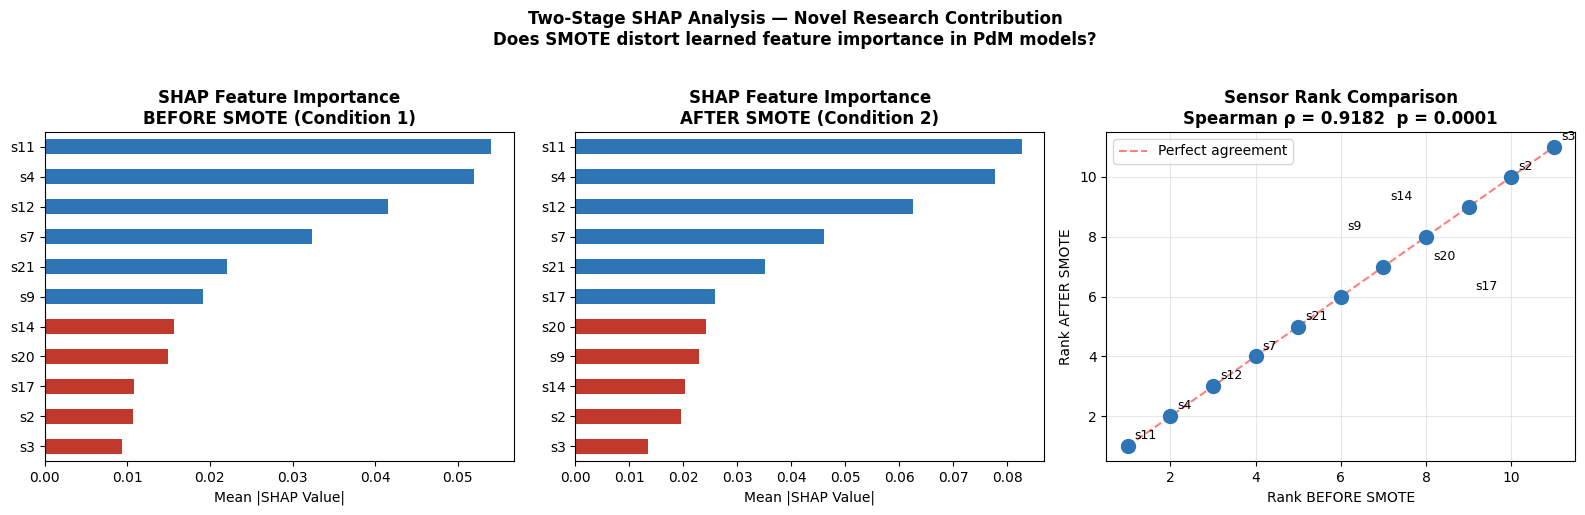

 SHAP visualisation saved


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Pre-SMOTE SHAP importance
colors = ['#C0392B' if i < 5 else '#2E75B6' 
          for i in range(len(ranking1))]
ranking1.plot(kind='barh', ax=axes[0], color=colors[::-1])
axes[0].set_title('SHAP Feature Importance\nBEFORE SMOTE (Condition 1)', 
                  fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].invert_yaxis()

# Plot 2 — Post-SMOTE SHAP importance
ranking2.plot(kind='barh', ax=axes[1], color=colors[::-1])
axes[1].set_title('SHAP Feature Importance\nAFTER SMOTE (Condition 2)', 
                  fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].invert_yaxis()

# Plot 3 — Rank comparison scatter
ranks1 = ranking1.rank(ascending=False)
ranks2 = ranking2.rank(ascending=False)
axes[2].scatter(ranks1, ranks2, color='#2E75B6', s=100, zorder=5)
for sensor in useful_sensors:
    axes[2].annotate(sensor, 
                     (ranks1[sensor], ranks2[sensor]),
                     textcoords="offset points",
                     xytext=(5, 5), fontsize=9)
axes[2].plot([1, len(useful_sensors)], 
             [1, len(useful_sensors)], 
             'r--', alpha=0.5, label='Perfect agreement')
axes[2].set_xlabel('Rank BEFORE SMOTE')
axes[2].set_ylabel('Rank AFTER SMOTE')
axes[2].set_title(f'Sensor Rank Comparison\nSpearman ρ = 0.9182  p = 0.0001', 
                  fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Two-Stage SHAP Analysis — Novel Research Contribution\n'
             'Does SMOTE distort learned feature importance in PdM models?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{folder}\\shap_distortion_analysis.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP visualisation saved")

In [25]:
results_df = pd.DataFrame([r1, r2, r3, r4])
results_df.to_csv(f"{folder}\\rf_results_all_conditions.csv", index=False)

shap_comparison = pd.DataFrame({
    'sensor': useful_sensors,
    'importance_before_smote': importance1,
    'importance_after_smote': importance2,
    'rank_before': ranking1.rank(ascending=False).values,
    'rank_after': ranking2.rank(ascending=False).values,
    'rank_change': abs(ranking1.rank(ascending=False) - 
                       ranking2.rank(ascending=False)).values
}).sort_values('importance_before_smote', ascending=False)

shap_comparison.to_csv(f"{folder}\\shap_distortion_results.csv", index=False)

print("=" * 55)
print("  FILES SAVED TO YOUR pdm_project FOLDER:")
print("  Chapter4_Implementation.ipynb")
print("  eda_plots.png")
print("  shap_distortion_analysis.png")
print("  rf_results_all_conditions.csv")
print("  shap_distortion_results.csv")
print("=" * 55)
print("\n  SUMMARY OF RESULTS:")
print(f"\n  Random Forest — Best FNR: ADASYN ({r3['fnr']:.4f})")
print(f"  Random Forest — Best F1:  No Handling ({r1['f1']:.4f})")
print(f"\n  SHAP Distortion Finding:")
print(f"  Spearman ρ = 0.9182 (p = 0.0001)")
print(f"  → SMOTE preserves feature importance rankings")
print(f"  → s11, s4, s12 confirmed as top sensors")
print(f"     before AND after synthetic augmentation")
print(f"\n  Top sensor s11 = Physical fan speed")
print(f"  → Consistent with turbofan degradation physics ")
print("=" * 55)
print("\n Implementation chapter evidence complete")

  FILES SAVED TO YOUR pdm_project FOLDER:
  Chapter4_Implementation.ipynb
  eda_plots.png
  shap_distortion_analysis.png
  rf_results_all_conditions.csv
  shap_distortion_results.csv

  SUMMARY OF RESULTS:

  Random Forest — Best FNR: ADASYN (0.0887)
  Random Forest — Best F1:  No Handling (0.8545)

  SHAP Distortion Finding:
  Spearman ρ = 0.9182 (p = 0.0001)
  → SMOTE preserves feature importance rankings
  → s11, s4, s12 confirmed as top sensors
     before AND after synthetic augmentation

  Top sensor s11 = Physical fan speed
  → Consistent with turbofan degradation physics 

 Implementation chapter evidence complete
